In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Data Preparation

In [22]:
df = pd.read_csv("HouseSale.csv")
df

,_________,____________,____________.1,________ (__),zone Rating,_______ (USD)
0,50.3,5,2,8,1,206042
1,50.9,2,1,21,1,179398
2,53.4,3,1,10,1,187509
3,56.4,5,3,8,1,242866
4,56.6,1,3,16,1,158455
...,...,...,...,...,...,...
356,497.4,5,2,26,5,1107045
357,499.5,3,2,19,5,1092027
358,499.6,1,3,12,5,1102534
359,499.6,5,1,23,5,1070454


In [23]:
df.shape

(361, 6)

In [24]:
df.isna().sum()

_________         0
____________      0
____________.1    0
________ (__)     0
zone Rating       0
_______ (USD)     0
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   _________       361 non-null    object
 1   ____________    361 non-null    object
 2   ____________.1  361 non-null    object
 3   ________ (__)   361 non-null    object
 4   zone Rating     361 non-null    object
 5   _______ (USD)   361 non-null    object
dtypes: object(6)
memory usage: 17.1+ KB


In [26]:
df = df.apply(pd.to_numeric, errors='coerce')

In [27]:
df.columns = [
    'sq_meters',   # ตารางเมตร
    'bedrooms',    # จำนวนห้องนอน
    'bathrooms',   # จำนวนห้องน้ำ
    'house_age',   # อายุบ้าน (ปี)
    'zone_rating', # zone Rating
    'price_usd'    # ราคาขาย (USD)
]

print(df.head())

   sq_meters  bedrooms  bathrooms  house_age  zone_rating  price_usd
0       50.3       5.0        2.0        8.0          1.0   206042.0
1       50.9       2.0        1.0       21.0          1.0   179398.0
2       53.4       3.0        1.0       10.0          1.0   187509.0
3       56.4       5.0        3.0        8.0          1.0   242866.0
4       56.6       1.0        3.0       16.0          1.0   158455.0


In [28]:
avg_max = df.agg(['mean', 'max'])
print(avg_max)

       sq_meters  bedrooms  bathrooms  house_age  zone_rating    price_usd
mean  277.084444  2.961111   1.969444  16.647222     3.627778   631059.675
max   499.600000  5.000000   3.000000  29.000000     5.000000  1108237.000


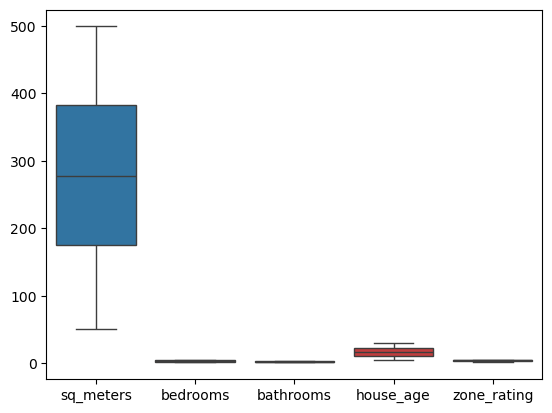

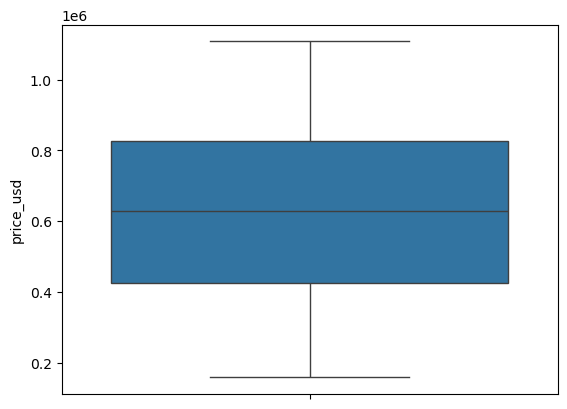

In [29]:
sns.boxplot(data=df.iloc[:, 0:5])
plt.show()

sns.boxplot(data=df.iloc[:, -1])
plt.show()

<Axes: >

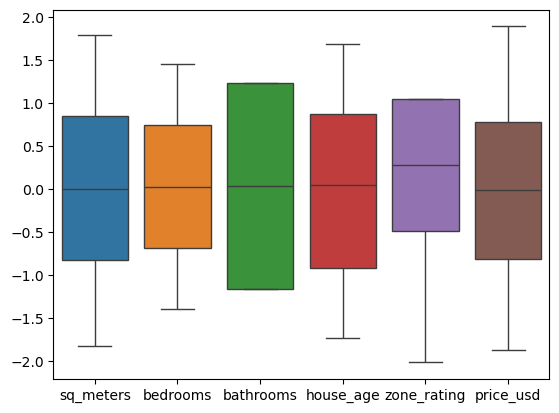

In [30]:
df_numeric = df.select_dtypes(include=['number']).drop(columns=['_______(USD)'], errors='ignore')

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)
df_scaled = pd.DataFrame(scaled_data, columns=df_numeric.columns)

sns.boxplot(data=df_scaled)

In [31]:
df_scaled = df_scaled.fillna(df_scaled.mean())

In [32]:
X = df_scaled.iloc[:, :-1]
y = df_scaled.iloc[:, -1]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

In [34]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=67)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 216
Validation size: 72
Test size: 73


In [35]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [36]:
print(f"Training Score:   {ridge_model.score(X_train, y_train):.4f}")
print(f"Validation Score: {ridge_model.score(X_val, y_val):.4f}")

Training Score:   0.9925
Validation Score: 0.9906


In [37]:
X_columns = X_train.columns

importance = pd.Series(ridge_model.coef_, index=X_columns)
print(importance.sort_values(ascending=False))

sq_meters      0.923739
zone_rating    0.069298
bedrooms       0.058581
bathrooms      0.027809
house_age     -0.025627
dtype: float64


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred_val = ridge_model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred_val)
mse = mean_squared_error(y_val, y_pred_val)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred_val)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

MAE: 0.08
MSE: 0.01
RMSE: 0.09
R2 Score: 0.99


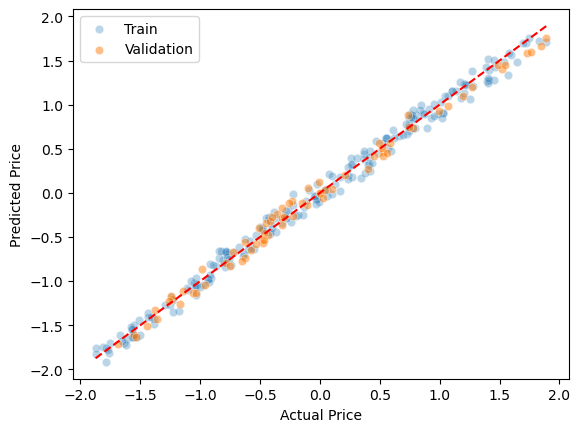

In [39]:
sns.scatterplot(x=y_train, y=ridge_model.predict(X_train), alpha=0.3, label='Train')
sns.scatterplot(x=y_val, y=y_pred_val, alpha=0.5, label='Validation')

plt.ylabel("Predicted Price")
plt.xlabel("Actual Price")
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=1.5)
plt.show()